In [2]:
import pandas as pd
from pathlib import Path

data_dir = Path("../data_raw")
print(data_dir.exists())
print(list(data_dir.iterdir()))

True
[PosixPath('../data_raw/wa_seattle_metro_zori_sfr_monthly_2000_2026_raw.csv'), PosixPath('../data_raw/wa_zip_median_income_acs_2019_2023-Column-Metadata.csv'), PosixPath('../data_raw/wa_zip_median_income_acs_2019_2023-Table-Notes.txt'), PosixPath('../data_raw/.us_zip_county_crosswalk_2025q4_raw.xlsx.icloud'), PosixPath('../data_raw/wa_zip_median_income_acs_2019_2023-Data.csv'), PosixPath('../data_raw/.wa_zip_zhvi_sfr_monthly_2000_2026_raw.csv.icloud')]


In [3]:
zori = pd.read_csv("../data_raw/wa_seattle_metro_zori_sfr_monthly_2000_2026_raw.csv")
zori.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,...,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31
0,102001,0,United States,country,NaN,1222.598517,1227.747546,1233.052032,1238.203928,1242.359611,...,2145.913411,2150.880528,2156.321184,2161.233991,2166.294540,2171.789164,2176.967890,2180.398935,2183.476173,2185.785211
1,394913,1,"New York, NY",msa,NY,2105.564662,2123.030446,2136.302980,2138.461029,2134.134452,...,3503.967232,3522.730561,3543.640323,3552.818565,3561.782556,3570.422692,3587.933860,3597.390212,3593.251669,3595.739949
2,753899,2,"Los Angeles, CA",msa,CA,2480.624575,2493.433996,2506.489988,2512.766515,2518.575893,...,4325.641339,4330.288436,4334.686035,4340.368051,4346.319843,4355.250707,4363.563400,4369.450766,4367.889692,4342.078938
3,394463,3,"Chicago, IL",msa,IL,1424.185073,1425.741919,1428.363068,1435.624580,1440.683985,...,2330.144957,2338.757647,2347.627163,2360.301976,2367.249281,2377.443687,2382.867085,2389.549878,2392.594995,2400.846396
4,394514,4,"Dallas, TX",msa,TX,1366.207489,1371.921432,1377.098800,1383.999883,1389.745508,...,2281.892751,2284.168494,2285.843375,2286.874491,2286.467474,2290.847100,2296.514269,2299.717329,2300.765669,2299.693263


In [4]:
zori[zori["RegionName"].str.contains("Seattle", na=False)]

,RegionID,SizeRank,RegionName,RegionType,StateName,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,...,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31
15,395078,15,"Seattle, WA",msa,WA,1751.17168,1760.908265,1773.008699,1777.845652,1786.352964,...,3116.690319,3123.199672,3134.797266,3140.718495,3149.352224,3151.622837,3163.881641,3163.744919,3168.000654,3169.070551


In [5]:
seattle_zori = zori[zori["RegionName"] == "Seattle, WA"]
seattle_zori

,RegionID,SizeRank,RegionName,RegionType,StateName,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,...,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31
15,395078,15,"Seattle, WA",msa,WA,1751.17168,1760.908265,1773.008699,1777.845652,1786.352964,...,3116.690319,3123.199672,3134.797266,3140.718495,3149.352224,3151.622837,3163.881641,3163.744919,3168.000654,3169.070551


In [6]:
seattle_zori_long = seattle_zori.melt(
    id_vars=["RegionName"],
    var_name="date",
    value_name="rent_index"
)

seattle_zori_long.head()

,RegionName,date,rent_index
0,"Seattle, WA",RegionID,395078
1,"Seattle, WA",SizeRank,15
2,"Seattle, WA",RegionType,msa
3,"Seattle, WA",StateName,WA
4,"Seattle, WA",2015-01-31,1751.17168


In [7]:
seattle_zori_long = seattle_zori.drop(
    columns=["RegionID", "SizeRank", "RegionType", "StateName"]
).melt(
    id_vars=["RegionName"],
    var_name="date",
    value_name="rent_index"
)

seattle_zori_long.head()

,RegionName,date,rent_index
0,"Seattle, WA",2015-01-31,1751.171680
1,"Seattle, WA",2015-02-28,1760.908265
2,"Seattle, WA",2015-03-31,1773.008699
3,"Seattle, WA",2015-04-30,1777.845652
4,"Seattle, WA",2015-05-31,1786.352964


In [8]:
seattle_zori_long["date"] = pd.to_datetime(seattle_zori_long["date"])

seattle_zori_long.dtypes

RegionName            object
date          datetime64[ns]
rent_index           float64
dtype: object

In [9]:
seattle_zori_long = seattle_zori_long.sort_values("date")

seattle_zori_long.head()

,RegionName,date,rent_index
0,"Seattle, WA",2015-01-31,1751.171680
1,"Seattle, WA",2015-02-28,1760.908265
2,"Seattle, WA",2015-03-31,1773.008699
3,"Seattle, WA",2015-04-30,1777.845652
4,"Seattle, WA",2015-05-31,1786.352964


In [10]:
seattle_zori_long["rent_growth"] = seattle_zori_long["rent_index"].pct_change()

seattle_zori_long.head()

,RegionName,date,rent_index,rent_growth
0,"Seattle, WA",2015-01-31,1751.171680,NaN
1,"Seattle, WA",2015-02-28,1760.908265,0.005560
2,"Seattle, WA",2015-03-31,1773.008699,0.006872
3,"Seattle, WA",2015-04-30,1777.845652,0.002728
4,"Seattle, WA",2015-05-31,1786.352964,0.004785


In [11]:
seattle_zori_long.to_csv("../data_clean/seattle_zori_clean.csv", index=False)

In [12]:
seattle_zori_long["rent_growth_yoy"] = seattle_zori_long["rent_index"].pct_change(12)

seattle_zori_long.head(15)

,RegionName,date,rent_index,rent_growth,rent_growth_yoy
0,"Seattle, WA",2015-01-31,1751.171680,NaN,NaN
1,"Seattle, WA",2015-02-28,1760.908265,0.005560,NaN
2,"Seattle, WA",2015-03-31,1773.008699,0.006872,NaN
3,"Seattle, WA",2015-04-30,1777.845652,0.002728,NaN
4,"Seattle, WA",2015-05-31,1786.352964,0.004785,NaN
5,"Seattle, WA",2015-06-30,1793.614129,0.004065,NaN
6,"Seattle, WA",2015-07-31,1810.512179,0.009421,NaN
7,"Seattle, WA",2015-08-31,1819.852864,0.005159,NaN
8,"Seattle, WA",2015-09-30,1830.825209,0.006029,NaN
9,"Seattle, WA",2015-10-31,1841.613810,0.005893,NaN


# ## Business Question 1
# How have Seattle rents changed over time?

# Goal:
# Understand long-term rent trends in the Seattle metropolitan area.

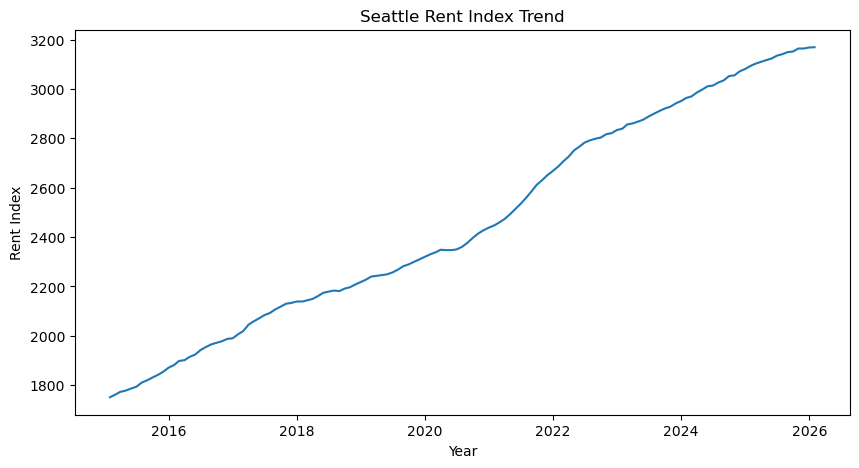

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(seattle_zori_long["date"], seattle_zori_long["rent_index"])

plt.title("Seattle Rent Index Trend")
plt.xlabel("Year")
plt.ylabel("Rent Index")

plt.show()

# ## Business Question 2
# What is the smoothed long-term trend of Seattle rents?

# Method:
# Use a 12-month rolling average to reduce short-term fluctuations.

In [14]:
seattle_zori_long["rent_rolling_12m"] = (
    seattle_zori_long["rent_index"]
    .rolling(window=12)
    .mean()
)

seattle_zori_long.head(15)

,RegionName,date,rent_index,rent_growth,rent_growth_yoy,rent_rolling_12m
0,"Seattle, WA",2015-01-31,1751.171680,NaN,NaN,NaN
1,"Seattle, WA",2015-02-28,1760.908265,0.005560,NaN,NaN
2,"Seattle, WA",2015-03-31,1773.008699,0.006872,NaN,NaN
3,"Seattle, WA",2015-04-30,1777.845652,0.002728,NaN,NaN
4,"Seattle, WA",2015-05-31,1786.352964,0.004785,NaN,NaN
5,"Seattle, WA",2015-06-30,1793.614129,0.004065,NaN,NaN
6,"Seattle, WA",2015-07-31,1810.512179,0.009421,NaN,NaN
7,"Seattle, WA",2015-08-31,1819.852864,0.005159,NaN,NaN
8,"Seattle, WA",2015-09-30,1830.825209,0.006029,NaN,NaN
9,"Seattle, WA",2015-10-31,1841.613810,0.005893,NaN,NaN


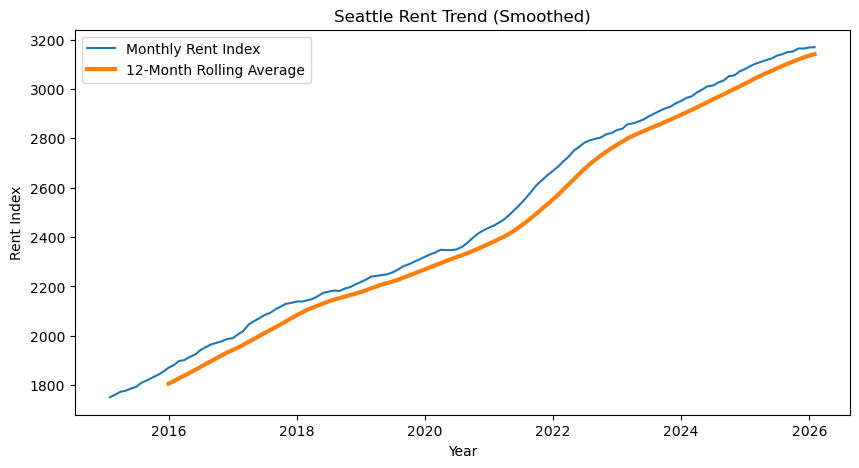

In [15]:
plt.figure(figsize=(10,5))

plt.plot(
    seattle_zori_long["date"],
    seattle_zori_long["rent_index"],
    label="Monthly Rent Index"
)

plt.plot(
    seattle_zori_long["date"],
    seattle_zori_long["rent_rolling_12m"],
    label="12-Month Rolling Average",
    linewidth=3
)

plt.title("Seattle Rent Trend (Smoothed)")
plt.xlabel("Year")
plt.ylabel("Rent Index")

plt.legend()

plt.show()

## Business Question 3
# What is the long-term compound growth rate of Seattle rents?

# Method:
# Calculate CAGR between the first and last observed rent levels.

In [16]:
start_rent = seattle_zori_long.iloc[0]["rent_index"]
end_rent = seattle_zori_long.iloc[-1]["rent_index"]

years = (
    seattle_zori_long.iloc[-1]["date"] -
    seattle_zori_long.iloc[0]["date"]
).days / 365

cagr = (end_rent / start_rent) ** (1 / years) - 1

print("Seattle Rent CAGR:", round(cagr * 100, 2), "%")

Seattle Rent CAGR: 5.54 %


# %%
seattle_zori_long["year"] = seattle_zori_long["date"].dt.year

yearly_growth = (
    seattle_zori_long
    .groupby("year")["rent_growth"]
    .mean()
)

yearly_growth

In [17]:
seattle_zori_long["year"] = seattle_zori_long["date"].dt.year

yearly_growth = (
    seattle_zori_long
    .groupby("year")["rent_growth"]
    .mean()
)

yearly_growth

year
2015    0.006027
2016    0.005164
2017    0.006036
2018    0.003025
2019    0.003744
2020    0.004173
2021    0.007533
2022    0.005032
2023    0.003386
2024    0.003603
2025    0.002327
2026    0.000338
Name: rent_growth, dtype: float64

In [18]:
yearly_rent = (
    seattle_zori_long
    .groupby("year")["rent_index"]
    .agg(["first", "last"])
)

yearly_rent["annual_growth"] = (
    yearly_rent["last"] - yearly_rent["first"]
) / yearly_rent["first"]

yearly_rent

,first,last,annual_growth
year,,,
2015,1751.171680,1870.796019,0.068311
2016,1881.435233,1990.010317,0.057709
2017,2006.575454,2138.945808,0.065968
2018,2138.885250,2217.847768,0.036918
2019,2227.889226,2319.536992,0.041137
2020,2330.041897,2438.293660,0.046459
2021,2447.416833,2667.998316,0.090128
2022,2686.499295,2833.548018,0.054736
2023,2839.196125,2950.809383,0.039312


## Business Question 5  
Are rents increasing faster than income in Seattle?

Goal:  
Evaluate housing affordability by comparing rent levels with household income.

In [20]:
income = pd.read_csv("../data_raw/wa_zip_median_income_acs_2019_2023-Data.csv")

income.head()

,GEO_ID,NAME,S1901_C01_001E,S1901_C01_001M,S1901_C01_002E,S1901_C01_002M,S1901_C01_003E,S1901_C01_003M,S1901_C01_004E,S1901_C01_004M,...,S1901_C04_012M,S1901_C04_013E,S1901_C04_013M,S1901_C04_014E,S1901_C04_014M,S1901_C04_015E,S1901_C04_015M,S1901_C04_016E,S1901_C04_016M,Unnamed: 130
0,Geography,Geographic Area Name,Estimate!!Households!!Total,Margin of Error!!Households!!Total,"Estimate!!Households!!Total!!Less than $10,000",Margin of Error!!Households!!Total!!Less than ...,"Estimate!!Households!!Total!!$10,000 to $14,999","Margin of Error!!Households!!Total!!$10,000 to...","Estimate!!Households!!Total!!$15,000 to $24,999","Margin of Error!!Households!!Total!!$15,000 to...",...,Margin of Error!!Nonfamily households!!Median ...,Estimate!!Nonfamily households!!Mean income (d...,Margin of Error!!Nonfamily households!!Mean in...,Estimate!!Nonfamily households!!PERCENT ALLOCA...,Margin of Error!!Nonfamily households!!PERCENT...,Estimate!!Nonfamily households!!PERCENT ALLOCA...,Margin of Error!!Nonfamily households!!PERCENT...,Estimate!!Nonfamily households!!PERCENT ALLOCA...,Margin of Error!!Nonfamily households!!PERCENT...,NaN
1,0400000US53,Washington,3064820,5874,3.9,0.1,2.5,0.1,4.6,0.1,...,479,88130,783,(X),(X),(X),(X),28.1,(X),NaN


In [21]:
income_clean = pd.read_csv(
    "../data_raw/wa_zip_median_income_acs_2019_2023-Data.csv",
    skiprows=1
)

income_clean.head()

,Geography,Geographic Area Name,Estimate!!Households!!Total,Margin of Error!!Households!!Total,"Estimate!!Households!!Total!!Less than $10,000","Margin of Error!!Households!!Total!!Less than $10,000","Estimate!!Households!!Total!!$10,000 to $14,999","Margin of Error!!Households!!Total!!$10,000 to $14,999","Estimate!!Households!!Total!!$15,000 to $24,999","Margin of Error!!Households!!Total!!$15,000 to $24,999",...,Margin of Error!!Nonfamily households!!Median income (dollars),Estimate!!Nonfamily households!!Mean income (dollars),Margin of Error!!Nonfamily households!!Mean income (dollars),Estimate!!Nonfamily households!!PERCENT ALLOCATED!!Household income in the past 12 months,Margin of Error!!Nonfamily households!!PERCENT ALLOCATED!!Household income in the past 12 months,Estimate!!Nonfamily households!!PERCENT ALLOCATED!!Family income in the past 12 months,Margin of Error!!Nonfamily households!!PERCENT ALLOCATED!!Family income in the past 12 months,Estimate!!Nonfamily households!!PERCENT ALLOCATED!!Nonfamily income in the past 12 months,Margin of Error!!Nonfamily households!!PERCENT ALLOCATED!!Nonfamily income in the past 12 months,Unnamed: 130
0,0400000US53,Washington,3064820,5874,3.9,0.1,2.5,0.1,4.6,0.1,...,479,88130,783,(X),(X),(X),(X),28.1,(X),NaN


In [22]:
income_clean.columns

Index(['Geography', 'Geographic Area Name', 'Estimate!!Households!!Total',
       'Margin of Error!!Households!!Total',
       'Estimate!!Households!!Total!!Less than $10,000',
       'Margin of Error!!Households!!Total!!Less than $10,000',
       'Estimate!!Households!!Total!!$10,000 to $14,999',
       'Margin of Error!!Households!!Total!!$10,000 to $14,999',
       'Estimate!!Households!!Total!!$15,000 to $24,999',
       'Margin of Error!!Households!!Total!!$15,000 to $24,999',
       ...
       'Margin of Error!!Nonfamily households!!Median income (dollars)',
       'Estimate!!Nonfamily households!!Mean income (dollars)',
       'Margin of Error!!Nonfamily households!!Mean income (dollars)',
       'Estimate!!Nonfamily households!!PERCENT ALLOCATED!!Household income in the past 12 months',
       'Margin of Error!!Nonfamily households!!PERCENT ALLOCATED!!Household income in the past 12 months',
       'Estimate!!Nonfamily households!!PERCENT ALLOCATED!!Family income in the past 12

In [23]:
[col for col in income_clean.columns if "Median income" in col]

['Estimate!!Households!!Median income (dollars)',
 'Margin of Error!!Households!!Median income (dollars)',
 'Estimate!!Families!!Median income (dollars)',
 'Margin of Error!!Families!!Median income (dollars)',
 'Estimate!!Married-couple families!!Median income (dollars)',
 'Margin of Error!!Married-couple families!!Median income (dollars)',
 'Estimate!!Nonfamily households!!Median income (dollars)',
 'Margin of Error!!Nonfamily households!!Median income (dollars)']

In [24]:
income_clean["Geographic Area Name"].unique()

array(['Washington'], dtype=object)

In [25]:
median_income_col = "Estimate!!Households!!Median income (dollars)"

income_value = income_clean[median_income_col].iloc[0]

income_value

98141

In [26]:
monthly_income = income_value / 12
monthly_income

8178.416666666667

In [27]:
seattle_zori_long["rent_to_income"] = (
    seattle_zori_long["rent_index"] / monthly_income
)

seattle_zori_long.head()

,RegionName,date,rent_index,rent_growth,rent_growth_yoy,rent_rolling_12m,year,rent_to_income
0,"Seattle, WA",2015-01-31,1751.171680,NaN,NaN,NaN,2015,0.214121
1,"Seattle, WA",2015-02-28,1760.908265,0.005560,NaN,NaN,2015,0.215312
2,"Seattle, WA",2015-03-31,1773.008699,0.006872,NaN,NaN,2015,0.216791
3,"Seattle, WA",2015-04-30,1777.845652,0.002728,NaN,NaN,2015,0.217383
4,"Seattle, WA",2015-05-31,1786.352964,0.004785,NaN,NaN,2015,0.218423


In [29]:
seattle_zori_long.tail()

,RegionName,date,rent_index,rent_growth,rent_growth_yoy,rent_rolling_12m,year,rent_to_income
128,"Seattle, WA",2025-09-30,3151.622837,0.000721,0.032593,3110.738064,2025,0.385359
129,"Seattle, WA",2025-10-31,3163.881641,0.003890,0.035647,3119.813056,2025,0.386857
130,"Seattle, WA",2025-11-30,3163.744919,-0.000043,0.030100,3127.516828,2025,0.386841
131,"Seattle, WA",2025-12-31,3168.000654,0.001345,0.028275,3134.776293,2025,0.387361
132,"Seattle, WA",2026-01-31,3169.070551,0.000338,0.024499,3141.091540,2026,0.387492


## Insight: Increasing Housing Pressure

The rent-to-income ratio in Seattle has increased significantly over the past decade.

In 2015, renters spent approximately 21% of their income on housing, which is considered affordable.

By 2025–2026, this ratio has risen to nearly 38–39%, approaching the threshold of financial stress.

This suggests that rent growth has substantially outpaced income growth, leading to increased housing affordability challenges.

In [30]:
seattle_zori_long[seattle_zori_long["rent_to_income"] > 0.3].head()

,RegionName,date,rent_index,rent_growth,rent_growth_yoy,rent_rolling_12m,year,rent_to_income
73,"Seattle, WA",2021-02-28,2459.243699,0.004832,0.052024,2392.843330,2021,0.300699
74,"Seattle, WA",2021-03-31,2473.503523,0.005798,0.053131,2403.242366,2021,0.302443
75,"Seattle, WA",2021-04-30,2492.189387,0.007554,0.061862,2415.341585,2021,0.304728
76,"Seattle, WA",2021-05-31,2513.833737,0.008685,0.071017,2429.232213,2021,0.307374
77,"Seattle, WA",2021-06-30,2534.805406,0.008343,0.078690,2444.641555,2021,0.309938


## Insight: Affordability Turning Point

The rent-to-income ratio in Seattle first exceeded the 30% affordability threshold in early 2021.

This marks a critical turning point where housing costs began to impose significant financial pressure on renters.

Since 2021, the ratio has continued to rise, reaching nearly 38–39% in recent years, indicating worsening affordability conditions.

## Business Implications

The rapid increase in rent relative to income suggests growing financial strain for renters in Seattle.

For policymakers, this highlights the need for affordable housing initiatives and rent stabilization measures.

For individuals, it indicates that housing costs may increasingly limit disposable income and savings potential.

For businesses and employers, rising housing costs may impact talent attraction and retention in the region.

## Visualization: Rent Affordability Over Time

This visualization highlights how rent affordability has changed over time in Seattle.

Key elements:
- Rent-to-income ratio trend
- 30% affordability threshold
- Turning point when affordability became a concern

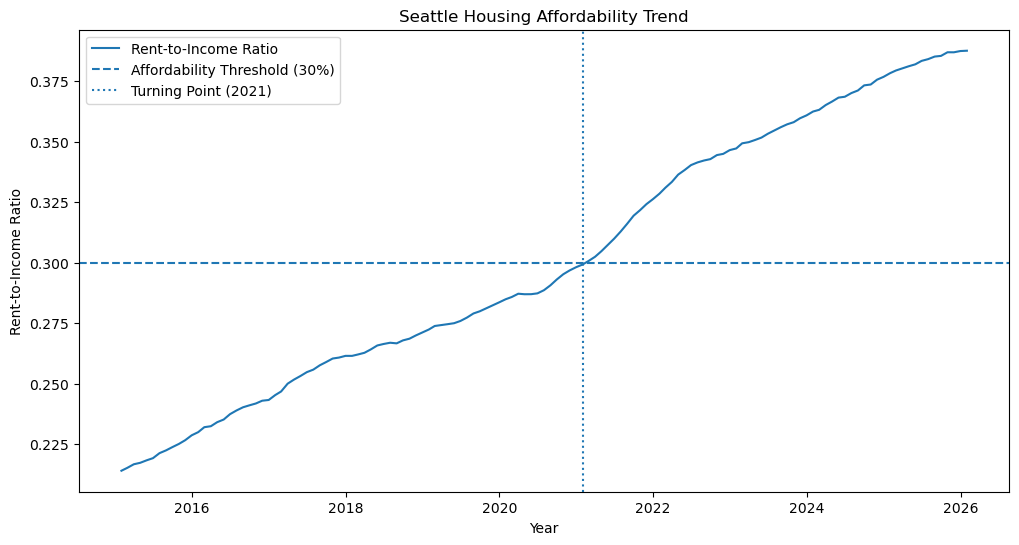

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    seattle_zori_long["date"],
    seattle_zori_long["rent_to_income"],
    label="Rent-to-Income Ratio"
)

plt.axhline(
    y=0.3,
    linestyle="--",
    label="Affordability Threshold (30%)"
)

plt.axvline(
    x=pd.to_datetime("2021-02-01"),
    linestyle=":",
    label="Turning Point (2021)"
)

plt.title("Seattle Housing Affordability Trend")
plt.xlabel("Year")
plt.ylabel("Rent-to-Income Ratio")

plt.legend()

plt.show()

## Insight from Visualization

The analysis reveals a significant deterioration in housing affordability in Seattle over the past decade.

- In 2015, renters spent approximately 21% of their income on housing, indicating a relatively affordable market.
- By early 2021, the rent-to-income ratio crossed the critical 30% threshold, marking the transition into a financially stressful environment.
- By 2025–2026, the ratio has increased to nearly 39%, suggesting that a substantial portion of income is now consumed by housing costs.

This trend indicates that rent growth has substantially outpaced income growth, resulting in increasing financial pressure on renters.

## Final Conclusion

This analysis shows that housing affordability in Seattle has deteriorated significantly over the past decade.

The combination of rising rents and relatively stagnant income has led to increasing financial strain for renters.

Future analysis could incorporate more granular data (e.g., county or ZIP-level income) to improve precision.

## Key Takeaways

- Seattle has transitioned from an affordable housing market to a high-cost, high-pressure environment over the past decade.
- The affordability threshold was crossed in 2021, marking a structural shift in housing conditions.
- Continued rent growth without proportional income growth may further reduce financial flexibility for residents.

This analysis highlights the importance of incorporating affordability metrics, rather than relying solely on price trends, when evaluating housing markets.

In [36]:
!pip install duckdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.2/14.2 MB 23.6 MB/s  0:00:00m0:00:010:01

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [37]:
import duckdb

In [38]:
con = duckdb.connect()

In [39]:
con.execute("""
CREATE TABLE seattle_rent AS
SELECT * FROM read_csv_auto('../data_clean/seattle_zori_clean.csv')
""")

## SQL-based Growth Analysis

To better understand how rental affordability has evolved over time, 
SQL window functions were used to calculate both short-term and long-term rent growth trends.

- Month-over-month growth captures short-term fluctuations in rental prices.
- Year-over-year growth reflects broader market trends and structural changes.

This approach provides a more comprehensive view of how rapidly rents are increasing, 
which is critical when evaluating whether income growth can keep pace with housing costs.

The use of SQL window functions also mirrors real-world analytical workflows 
commonly used in production data environments.

In [40]:
con.execute("""
SELECT
    date,
    rent_index,
    
    -- Monthly growth
    rent_index / LAG(rent_index) OVER (ORDER BY date) - 1 AS rent_growth,

    -- Year-over-year growth
    rent_index / LAG(rent_index, 12) OVER (ORDER BY date) - 1 AS rent_growth_yoy

FROM seattle_rent
ORDER BY date
""").df()

,date,rent_index,rent_growth,rent_growth_yoy
0,2015-01-31,1751.171680,NaN,NaN
1,2015-02-28,1760.908265,0.005560,NaN
2,2015-03-31,1773.008699,0.006872,NaN
3,2015-04-30,1777.845652,0.002728,NaN
4,2015-05-31,1786.352964,0.004785,NaN
...,...,...,...,...
128,2025-09-30,3151.622837,0.000721,0.032593
129,2025-10-31,3163.881641,0.003890,0.035647
130,2025-11-30,3163.744919,-0.000043,0.030100
131,2025-12-31,3168.000654,0.001345,0.028275


## Insights from SQL Analysis

The results show that rent growth has remained consistently positive over time, 
with a noticeable acceleration after 2020.

Year-over-year growth indicates sustained increases in rental prices, 
suggesting strong and persistent demand in the housing market.

Importantly, this level of rent growth is unlikely to be matched by income growth, 
implying a widening affordability gap for renters.

This reinforces the conclusion that housing affordability in Seattle has structurally deteriorated over time.

In [44]:
df_sql = con.execute("""
SELECT
    date,
    rent_index,
    
    rent_index / 8178 AS rent_to_income,

    rent_index / LAG(rent_index) OVER (ORDER BY date) - 1 AS rent_growth,

    rent_index / LAG(rent_index, 12) OVER (ORDER BY date) - 1 AS rent_growth_yoy

FROM seattle_rent
ORDER BY date
""").df()

In [45]:
df_sql.to_csv("../outputs/rent_growth_analysis.csv", index=False)